In [1]:
import tensorflow as tf
import glob
import numpy as np
import pandas as pd
import math
import time
import statistics
from tqdm import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
tf.config.run_functions_eagerly(True)

filterSilence=True
#Run with or without tensorflow_probability

"""
TODO:
Could select only real data with events. Done
Import my save.txt routine to optionally write output.
Rename the To TC with rate constants K13 K12 K23 etc.
Would another state help? I don't think so... 4 states should capture realistic bursting.
Could draw the transition matrix as a graph too? Too fancy. User can do this.
Noise could be more authentic still. 
a. Some slow-wave. freq, phase, amp.
b. Some open channel noise. tf.boolean_mask ...if open add white noise? could be slow.
c. replace noise with Sam noise? was it all TF?
d. SPIKE GENERATION SHOULD BE CHANGED, max should be x not abs(x) and number should be abs(x) not be abs(x) +1. X
e. pink noise should also be tf.function decorated!! X
f. WE ARE USING PROBABILITIES NOT RATES SO NEED TO ADAPT OR CORRECT BEFORE WRITING TO FILE!

F:: concerned about whether I have consistent use of dt.  In some places it seems with have an array that is size long. In other places this is called 
size and sometimes steps are 1 long and others they are df long @@
OK ...looks like the only time dt is used is when plotting simulated output.

CHANNEL IS LANE 0
RAW IS LANE 1

RUNNING ON MBP metal_101 env (102 doesn't work!). TF version 2.16 I believe. 
pip install tensorflow-macos tensorflow-metal
NB:
This version irrationally markovian simulates two channels but only ever uses the first 

"""
import os
import logging

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # '0' = all logs, '1' = filter out INFO logs, '2' = filter out WARNING logs, '3' = filter out ERROR logs

# Suppress other warnings
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Additional suppression for TensorFlow 2.x
tf.get_logger().setLevel('ERROR')

"""claude suggested this can improve performance
tf.keras.mixed_precision.set_global_policy('mixed_float16')"""

# List all physical GPUs
gpus = tf.config.list_physical_devices('GPU')
#tf.config.optimizer.set_jit(True)
#tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f"Number of GPUs detected: {len(gpus)}")


2024-11-05 23:33:25.039726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-05 23:33:25.088694: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-05 23:33:25.102571: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-05 23:33:25.131947: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-05 23:33:26.688656: W tensorflow/compiler/tf2tenso

Number of GPUs detected: 1


I0000 00:00:1730849609.922713  238387 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1730849609.984913  238387 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1730849609.985041  238387 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
n = 1  # Number of channels
dt = tf.constant(0.1, dtype=tf.float32)

#Must be a multiple of 2!!!
#Size of channel (relative to the channels so one channel
size=1000
batch_size=100
buffer=100 #in from each edge
crop=size-buffer

I0000 00:00:1730849610.007616  238387 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1730849610.008169  238387 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1730849610.008301  238387 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1730849610.491981  238387 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1730849610.492128  238387 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-11-05

In [3]:
def create_dataset(fake_data, batch_size):
    # Calculate number of complete batches
    n_samples = len(fake_data)
    n_batches = n_samples // batch_size
    
    # Trim data to be evenly divisible by batch_size
    trimmed_size = n_batches * batch_size
    trimmed_data = fake_data[:trimmed_size]
    
    # Create dataset with proper shuffling and repeat
    dataset = tf.data.Dataset.from_tensor_slices(trimmed_data)
    dataset = dataset.shuffle(buffer_size=len(trimmed_data))
    dataset = dataset.batch(batch_size, drop_remainder=True)
    dataset = dataset.repeat()  # Add repeat() here
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


"""also suggested this
def create_dataset(data, batch_size):
    # Print diagnostic information
    print(f"Creating dataset with {len(data)} samples")
    print(f"Data shape: {data.shape}")
    
    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices(data)
    
    # Add shuffling before batching
    dataset = dataset.shuffle(buffer_size=min(len(data), 10000))
    
    # Batch the data, dropping remainder to ensure consistent batch sizes
    dataset = dataset.batch(batch_size, drop_remainder=True)
    
    # Add repeat AFTER batching
    dataset = dataset.repeat()
    
    # Add prefetching
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset   
    """

'also suggested this\ndef create_dataset(data, batch_size):\n    # Print diagnostic information\n    print(f"Creating dataset with {len(data)} samples")\n    print(f"Data shape: {data.shape}")\n    \n    # Create dataset\n    dataset = tf.data.Dataset.from_tensor_slices(data)\n    \n    # Add shuffling before batching\n    dataset = dataset.shuffle(buffer_size=min(len(data), 10000))\n    \n    # Batch the data, dropping remainder to ensure consistent batch sizes\n    dataset = dataset.batch(batch_size, drop_remainder=True)\n    \n    # Add repeat AFTER batching\n    dataset = dataset.repeat()\n    \n    # Add prefetching\n    dataset = dataset.prefetch(tf.data.AUTOTUNE)\n    \n    return dataset   \n    '

In [4]:
def throw_unchanged(training_data, max_unchanged=10):
    # Get first column
    first_column = training_data[:, :, 0]
    
    # Calculate if each sequence is unchanged
    mins = tf.reduce_min(first_column, axis=1)
    maxs = tf.reduce_max(first_column, axis=1)
    all_same = tf.equal(mins, maxs)
    
    # Convert to numpy for easier handling
    all_same_np = all_same.numpy()
    total_records = len(training_data)
    unchanged_count = np.sum(all_same_np)
    unchanged_percent = (unchanged_count / total_records) * 100
    print(f"Initial unchanged count: {unchanged_count} out of {total_records}")
    changed = total_records - unchanged_count
    print(f"Initial percentage unchanged: {unchanged_percent:.1f}%")
    
    if unchanged_percent > max_unchanged:
        # Calculate how many unchanged to keep
        keep_count = int(changed * max_unchanged/100)
        print(f"\nKeeping {keep_count} unchanged sequences")
        
        # Get indices of changed and unchanged records
        changed_indices = np.where(~all_same_np)[0]    # All changing sequences
        unchanged_indices = np.where(all_same_np)[0]   # All unchanged sequences
        
        # Randomly select from unchanged
        keep_unchanged_indices = np.random.choice(unchanged_indices, keep_count, replace=False)
        
        # Combine both sets of indices
        keep_indices = np.concatenate([changed_indices, keep_unchanged_indices])
        
        # Sort indices to maintain original order
        keep_indices = np.sort(keep_indices)
        
        # Apply the indices to filter the data
        training_data = tf.gather(training_data, keep_indices)
        
        # Verify final percentages
        final_mins = tf.reduce_min(training_data[:, :, 0], axis=1)
        final_maxs = tf.reduce_max(training_data[:, :, 0], axis=1)
        final_unchanged = tf.equal(final_mins, final_maxs).numpy()
        final_unchanged_percent = (np.sum(final_unchanged) / len(training_data)) * 100
        print(f"\nFinal unchanged count: {np.sum(final_unchanged)} out of {len(training_data)}")
        print(f"Final percentage unchanged: {final_unchanged_percent:.1f}%")
    
    print(f"\nFinal dataset size: {tf.shape(training_data)[0]}")
    return training_data

In [5]:
def augment_tensor_with_noise(data, n_copies, noise_std=1e-6):
    """
    Create n copies of input tensor and add noise to the second channel
    
    Args:
        data: Input tensor of shape (x, 1000, 2)
        n_copies: Number of copies to create
        noise_std: Standard deviation of Gaussian noise to add
        
    Returns:
        Augmented tensor of shape (n*x, 1000, 2)
    """
    x = data.shape[0]
    
    # Create n copies
    augmented = np.tile(data, (n_copies, 1, 1))
    
    # Add noise only to second channel (:,:,1)
    noise = np.random.normal(0, noise_std, size=(n_copies*x, 1000))
    augmented[:,:,1] += noise
    
    return augmented

# Example usage:
# original_data = np.random.rand(10, 1000, 2)  # Example data
# augmented_data = augment_tensor_with_noise(original_data, n_copies=5)
# print(augmented_data.shape)  # Will show (50, 1000, 2)

In [6]:
import numpy as np
from scipy.interpolate import interp1d

def generate_perlin_noise_1d(length, octaves=4, persistence=0.5, lacunarity=2.0):
    """
    Generate 1D Perlin noise with multiple octaves
    
    Args:
        length: Length of output array
        octaves: Number of octaves for fBm
        persistence: Amplitude decrease factor per octave
        lacunarity: Frequency increase factor per octave
    """
    noise = np.zeros(length)
    max_amplitude = 0
    
    for i in range(octaves):
        # Generate base random values
        period = max(2, int(length // (lacunarity ** i)))  # Fix: Convert to int and ensure minimum of 2
        
        # Create random gradients
        gradients = np.random.randn(period + 1)
        
        # Create regular points for interpolation
        x_vals = np.linspace(0, period, period + 1)
        distances = np.linspace(0, period, length)
        
        # Interpolate between gradients
        interp = interp1d(x_vals, gradients, kind='cubic')
        amplitude = persistence ** i
        noise += interp(distances) * amplitude
        max_amplitude += amplitude
        
    # Normalize
    return noise / max_amplitude

def generate_fbm_noise(length, hurst=0.7, octaves=4):
    """
    Generate fractional Brownian motion noise
    
    Args:
        length: Length of output array
        hurst: Hurst parameter (0.5 for regular Brownian motion, >0.5 for persistent)
        octaves: Number of octaves to sum
    """
    noise = np.zeros(length)
    frequencies = np.fft.fftfreq(length)
    frequencies[0] = 1e-6  # Avoid division by zero
    
    # Generate spectrum following power law
    amplitudes = np.abs(frequencies) ** (-2 * hurst - 1)
    phases = 2 * np.pi * np.random.rand(length)
    
    # Create complex spectrum
    spectrum = amplitudes * (np.cos(phases) + 1j * np.sin(phases))
    
    # Inverse FFT to get time series
    noise = np.fft.ifft(spectrum).real
    return (noise - noise.mean()) / noise.std()

def augment_tensor_with_sophisticated_noise(data, n_copies, base_noise_std=1e-6, 
                                         hurst=0.7, octaves=4, perlin_weight=0.3):
    """
    Create n copies of input tensor and add sophisticated noise combining fBm and Perlin noise
    
    Args:
        data: Input tensor of shape (x, 1000, 2)
        n_copies: Number of copies to create
        base_noise_std: Base standard deviation for noise scaling
        hurst: Hurst parameter for fBm (0.5-0.9, higher = more persistent)
        octaves: Number of octaves for both noise types
        perlin_weight: Weight of Perlin noise vs fBm (0-1)
    
    Returns:
        Augmented tensor of shape (n*x, 1000, 2)
    """
    x, time_steps, channels = data.shape
    augmented = np.tile(data, (n_copies, 1, 1))
    
    # Generate noise for each copy
    for i in range(n_copies * x):
        # Generate both types of noise
        fbm = generate_fbm_noise(time_steps, hurst, octaves)
        perlin = generate_perlin_noise_1d(time_steps, octaves)
        
        # Combine noises
        combined_noise = (perlin_weight * perlin + 
                        (1 - perlin_weight) * fbm)
        
        # Normalize and scale
        combined_noise = (combined_noise - combined_noise.mean()) / combined_noise.std()
        combined_noise *= base_noise_std
        
        # Add to second channel only
        augmented[i, :, 1] += combined_noise
    
    return augmented

In [7]:
#Create REAL Trainging Data
# Load all parquet files from directory
file_paths = glob.glob("2024_06_17/combo/*.parquet")  # Adjust path as needed
dfs = []

for file_path in file_paths:
    print(file_path, end=":")
    temp_df = pd.read_parquet(file_path)
    temp_df = temp_df[["Channels","Noisy Current"]]
    dfs.append(temp_df-temp_df.round().mode().iloc[0])
    
# Concatenate all files
df = pd.concat(dfs, ignore_index=True)
max_channels = df["Channels"].max()
print("Max channels:", max_channels)

# optionally add more noise
# Sean files huge. Decimate them
df = df[::10]
NOISE = True

print("\nStand by - we're minMax scaling the lot")
scaler = MinMaxScaler(feature_range=(-1, 1))
df[["Channels", "Noisy Current"]] = scaler.fit_transform(df[["Channels", "Noisy Current"]])
data_array = df.to_numpy()

data_array = tf.convert_to_tensor(data_array, dtype=tf.float32)
training_data = tf.reshape(data_array, [-1, size, 2])

if filterSilence:
    print("\nBefore throwing",training_data.shape)
    print("\n",training_data.shape)
    print("Throwing away unchanged")
    training_data = throw_unchanged(training_data, max_unchanged=1)
print("\nFinal Size:",training_data.shape)
if NOISE:
    training_data = augment_tensor_with_sophisticated_noise(training_data, n_copies=25, base_noise_std=1e-4, 
                                         hurst=0.7, octaves=4, perlin_weight=0.3)
    print("\nFinal Size:",training_data.shape)

2024_06_17/combo/cell_3_hek_bkca_0000_stmball_-60.0_20.parquet:2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_38.parquet:2024_06_17/combo/cell_3_hek_bkca_0000_stmball_-60.0_1.parquet:2024_06_17/combo/cell_3_hek_bkca_0000_stmball_-60.0_22.parquet:2024_06_17/combo/cell_3_hek_bkca_0000_stmball_-60.0_7.parquet:2024_06_17/combo/cell_3_hek_bkca_0000_stmball_-60.0_0.parquet:2024_06_17/combo/cell_3_hek_bkca_0000_stmball_-60.0_25.parquet:2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_12.parquet:2024_06_17/combo/cell_3_hek_bkca_0000_stmball_-60.0_4.parquet:2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_28.parquet:2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_47.parquet:2024_06_17/combo/cell_3_hek_bkca_0000_stmball_-60.0_30.parquet:2024_06_17/combo/cell_3_hek_bkca_0000_stmball_-60.0_12.parquet:2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_44.parquet:2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_16.parquet:2024_06_17/combo/cell_1 hek_bkca_0000_stmball_-60.0_35.parq

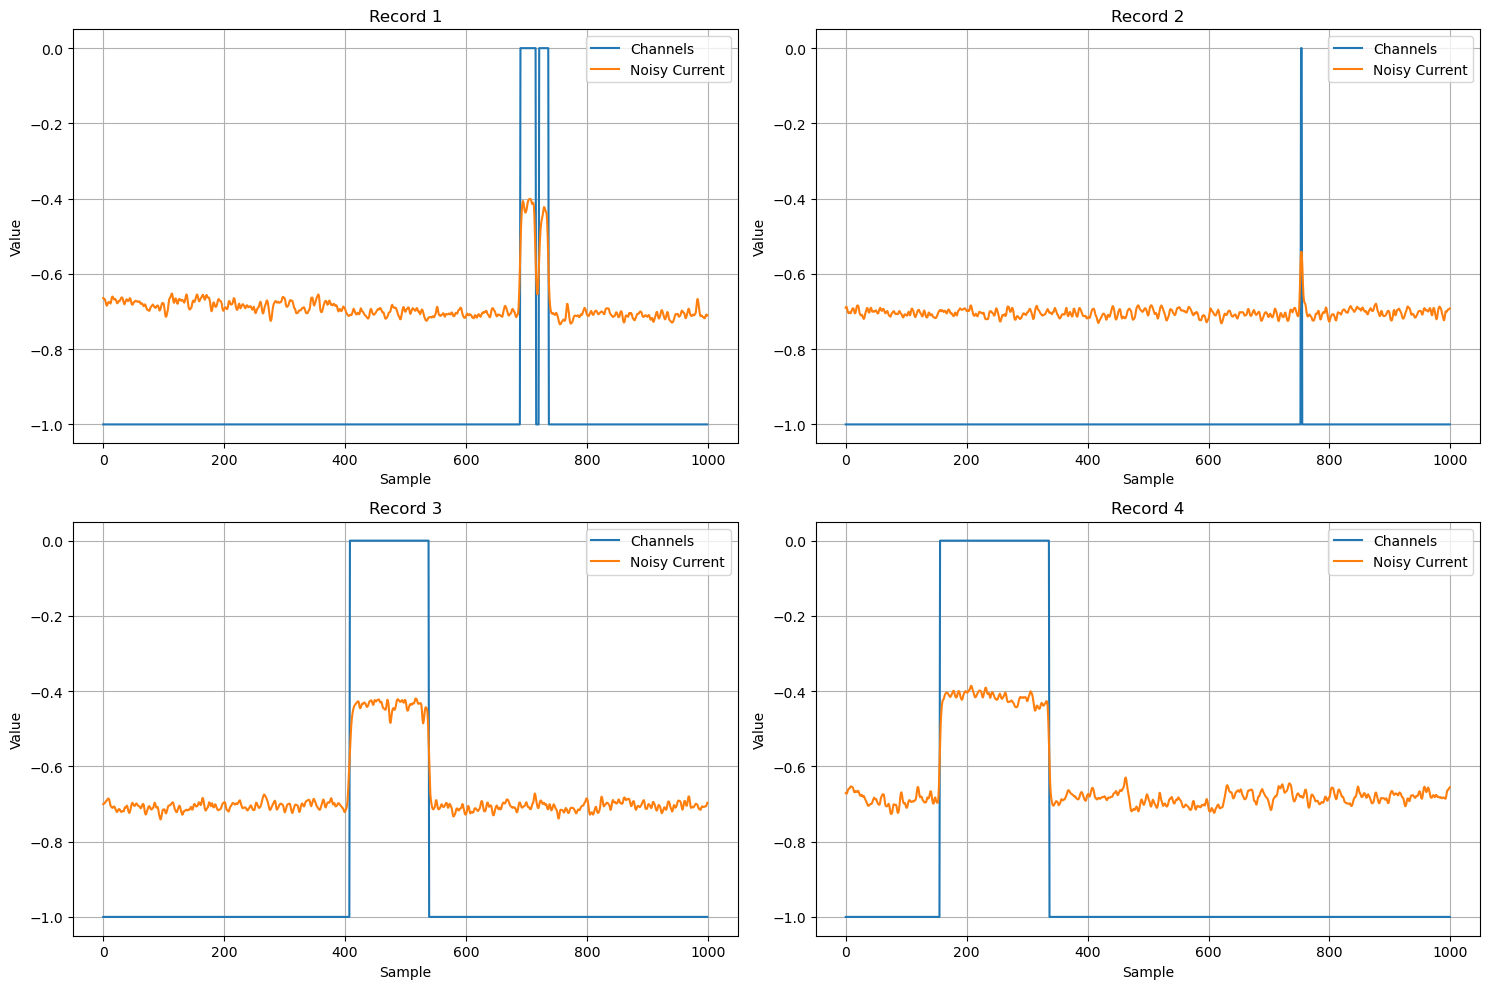


Record 1:
Channel range: -1.00 to 0.00
Raw signal range: -0.73 to -0.40

Record 2:
Channel range: -1.00 to 0.00
Raw signal range: -0.73 to -0.54

Record 3:
Channel range: -1.00 to 0.00
Raw signal range: -0.74 to -0.42

Record 4:
Channel range: -1.00 to 0.00
Raw signal range: -0.73 to -0.39


In [8]:
import matplotlib.pyplot as plt

def plot_n_records(data, n):
    # Calculate grid dimensions
    rows = int(np.ceil(n/2))
    cols = min(2, n)  # Use 2 columns unless n=1
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
    if n == 1:
        axes = np.array([axes])  # Make single axis iterable
    axes = axes.ravel()  # Flatten the array for easier indexing

    for i in range(n):
        axes[i].plot(data[i, :, 0], label='Channels')
        axes[i].plot(data[i, :, 1], label='Noisy Current')
        axes[i].set_title(f'Record {i+1}')
        axes[i].grid(True)
        axes[i].legend()
        axes[i].set_xlabel('Sample')
        axes[i].set_ylabel('Value')
    
    # Turn off any unused subplots
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

    # Print stats for each record
    for i in range(n):
        print(f"\nRecord {i+1}:")
        print(f"Channel range: {tf.reduce_min(data[i, :, 0]):.2f} to {tf.reduce_max(data[i, :, 0]):.2f}")
        print(f"Raw signal range: {tf.reduce_min(data[i, :, 1]):.2f} to {tf.reduce_max(data[i, :, 1]):.2f}")

# Now you can call it with any number
n = 4  # Change this to however many you want to see
plot_n_records(training_data, n)

In [9]:
import numpy as np
from scipy.interpolate import interp1d

def generate_sophisticated_noise(shape, noise_std=0.1, hurst=0.7, octaves=4, perlin_weight=0.3):
    """
    Generate sophisticated noise combining Perlin and fBm noise
    """
    noise = np.zeros(shape)
    
    for i in range(shape[0]):
        fbm = generate_fbm_noise(shape[1], hurst, octaves)
        perlin = generate_perlin_noise_1d(shape[1], octaves)
        
        combined_noise = (perlin_weight * perlin + (1 - perlin_weight) * fbm)
        combined_noise = (combined_noise - combined_noise.mean()) / combined_noise.std()
        combined_noise *= noise_std
        
        noise[i] = combined_noise
    
    return noise

def generate_perlin_noise_1d(length, octaves=4, persistence=0.5, lacunarity=2.0):
    """
    Generate 1D Perlin noise with multiple octaves
    """
    noise = np.zeros(length)
    max_amplitude = 0
    
    for i in range(octaves):
        period = max(2, int(length // (lacunarity ** i)))
        gradients = np.random.randn(period + 1)
        x_vals = np.linspace(0, period, period + 1)
        distances = np.linspace(0, period, length)
        
        interp = interp1d(x_vals, gradients, kind='cubic')
        amplitude = persistence ** i
        noise += interp(distances) * amplitude
        max_amplitude += amplitude
    
    return noise / max_amplitude

def generate_fbm_noise(length, hurst=0.7, octaves=4):
    """
    Generate fractional Brownian motion noise
    """
    noise = np.zeros(length)
    frequencies = np.fft.fftfreq(length)
    frequencies[0] = 1e-6
    
    amplitudes = np.abs(frequencies) ** (-2 * hurst - 1)
    phases = 2 * np.pi * np.random.rand(length)
    
    spectrum = amplitudes * (np.cos(phases) + 1j * np.sin(phases))
    noise = np.fft.ifft(spectrum).real
    return (noise - noise.mean()) / noise.std()

def add_noisy_channel(data, noise_std=0.1, hurst=0.7, octaves=4, perlin_weight=0.3):
    """
    Create a copy of the input array where the second channel is the first channel plus sophisticated noise.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Input array of shape (N, M, 2)
    noise_std : float
        Standard deviation of the noise to add
    hurst : float
        Hurst parameter for fBm (0.5-0.9, higher = more persistent)
    octaves : int
        Number of octaves for noise generation (higher = more detail)
    perlin_weight : float
        Weight of Perlin noise vs fBm (0-1)
        
    Returns:
    --------
    numpy.ndarray
        Copy of input array with noisy second channel
    """
    # Create a copy to avoid modifying the original
    result = data.copy()
    
    # Generate sophisticated noise
    noise = generate_sophisticated_noise(
        shape=data.shape[:-1],
        noise_std=noise_std,
        hurst=hurst,
        octaves=octaves,
        perlin_weight=perlin_weight
    )
    
    # Add noise to the copy of the first channel
    result[..., 1] = result[..., 0] + noise
    
    return result


    # Add noisy channel
    result = add_noisy_channel(
        sample_data,
        noise_std=0.1,
        hurst=0.7,
        octaves=4,
        perlin_weight=0.3
    )
    
""" USE THE SIMPLER ONE!"""
def add_noisy_channel(data, noise_std=0.1):

    """
    Create a copy of the input array where the second channel is the first channel plus Gaussian noise.
    
    Parameters:
    -----------
    data : numpy.ndarray
        Input array of shape (N, M, 2)
    noise_std : float
        Standard deviation of the Gaussian noise to add
        
    Returns:
    --------
    numpy.ndarray
        Copy of input array with noisy second channel """

    # Create a copy to avoid modifying the original
    result = data.copy()
    
    # Generate Gaussian noise with the same shape as one channel
    noise = np.random.normal(0, noise_std, size=data.shape[:-1])

    # Add noise to the copy of the first channel
    result[..., 1] = result[..., 0] + noise
    return result
    
data = add_noisy_channel(training_data, noise_std=0.1)

In [10]:
print(data.shape)

(50425, 1000, 2)


In [11]:
#Now using the above method!
SIMULATED = False
if SIMULATED:
    data1 = pd.read_csv("medium template.csv")
    data2 = pd.read_csv("single channel template.csv")
    """
    data1 = pd.read_csv("INaNoiseTemplate.csv")
    # Concatenate the dataframes"""
    data = pd.concat([data1, data2], axis=0)
    # data = data2
    # Convert to numpy array
    data = data[["Channels","Noisy Current"]].to_numpy(dtype="float32")
    
    # Now you can use numpy indexing
    max_value = data[:,0].max()
    #del data2, data1

In [12]:
data[:,0].max()

1.2713394

In [13]:
num_samples = 10000
fake_data = data.reshape(-1,size,2)
fake_data = throw_unchanged(fake_data, max_unchanged=5)
print(fake_data.shape)
del data
if fake_data.shape[0] > num_samples:
    random_indices = np.random.choice(fake_data.shape[0], size=num_samples, replace=False)
    fake_data = fake_data[random_indices,:,:]
num_samples = fake_data.shape[0]
print(fake_data.shape)
print(fake_data.dtype)

Initial unchanged count: 475 out of 50425
Initial percentage unchanged: 0.9%

Final dataset size: 50425
(50425, 1000, 2)
(10000, 1000, 2)
float32


In [14]:
"""max channels in this case is 2 so need to throw any records with channels more than that or it will later throw the min max
scaler need to reorder since we calculate max_channels later!!! from the real data!"""
"""tf version
fake_data_filtered = tf.boolean_mask(fake_data, valid_cols, axis=0)"""

valid_cols = ~np.any(fake_data[:, :, 0] > max_channels, axis=1)
print(valid_cols.shape)
fake_data = fake_data[valid_cols, :, :]
print(fake_data.shape)



(10000,)
(10000, 1000, 2)


In [15]:
def add_blank_records(data, percentage=5):
    """
    Add blank records to a numpy array/dataframe based on a percentage of original size.
    
    Parameters:
    data: numpy array or dataframe - The original dataset
    percentage: int - Percentage of original size to add as blanks (default 20)
    
    Returns:
    Combined array with original data and blank records
    """
    #How many blanks are there now?
    first_column = data[:, :, 0]
    
    # Calculate if each sequence is unchanged
    mins = tf.reduce_min(first_column, axis=1)
    maxs = tf.reduce_max(first_column, axis=1)
    all_same = tf.equal(mins, maxs)
    
    # Convert to numpy for easier handling
    all_same_np = all_same.numpy()
    total_records = len(training_data)
    unchanged_count = np.sum(all_same_np)
    unchanged_percent = (unchanged_count / total_records) * 100
    if unchanged_percent < percentage:
        percentage = percentage - unchanged_percent
        # Calculate number of blank records to add
        num_blanks = int((percentage / 100) * data.shape[0])
        
        # Create blank records with same number of columns as original data
        blank_records = np.zeros(shape=(num_blanks, data.shape[1],2))
        
        # Combine original data with blank records
        combined_data = np.vstack([data, blank_records])
        print(f"Added {num_blanks} blank records")
    print(f"Original shape: {data.shape}")
    print(f"Final shape: {combined_data.shape}")
    
    return combined_data.astype(np.float32)
"""Add back 5% of blanks
Can't do this if using the noisy signal!!
"""
#fake_data = add_blank_records(fake_data)

"Add back 5% of blanks\nCan't do this if using the noisy signal!!\n"

In [16]:
 # we are going to throw away the noisy current (it is there for legacy reasons - wasting memory)
 # but we should minmax the other channel to match the training data itself
fake_min = np.min(fake_data[:,:,0])
fake_max = np.max(fake_data[:,:,0])
print(f"Before Scaling: Min {fake_min}, Mx {fake_max}")
fake_data[:,:,0] = 2 * ( (fake_data[:,:,0] - fake_min)/(fake_max-fake_min) ) - 1
fake_min = np.min(fake_data[:,:,0])
fake_max = np.max(fake_data[:,:,0])
print(f"After scaling: Min {fake_min}, Mx {fake_max}")
print(fake_data.dtype)

Before Scaling: Min -1.0, Mx 1.0
After scaling: Min -1.0, Mx 1.0
float32


In [17]:
fake_data.dtype

dtype('float32')

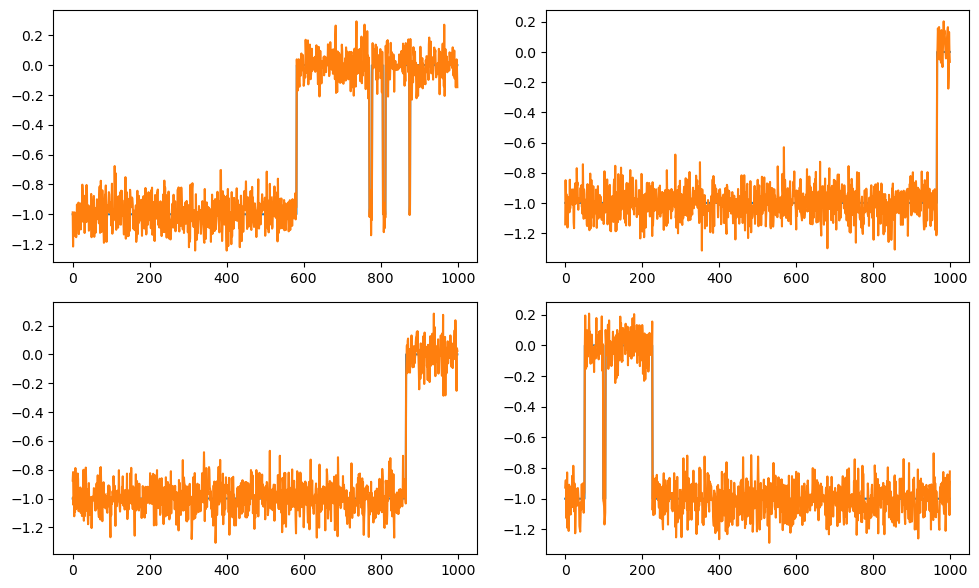

In [18]:
def plotter(data):
    # Create a figure with two subplots (panels)
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
     # Flatten the axs array for easy iteration
    axs = axs.flatten()
    
    for i in range(4):
        axs[i].plot(data[i])
        #axs[i].set_ylim([-200, 200])
    plt.tight_layout()
    plt.show()

plotter(fake_data)

In [19]:
fake_dataset = create_dataset(fake_data, batch_size)

In [20]:
# Define the generator model
gen_input_len=size

def initialize_lowpass_layer(kernel_size, cutoff_freq, method='gaussian', fs=1.0):
    """
    Initialize Conv1D weights for different types of lowpass filters
    
    Parameters:
    kernel_size: int, size of the filter kernel
    cutoff_freq: float, cutoff frequency (normalized to fs/2)
    method: str, type of filter ('gaussian', 'moving_avg', 'hamming', 'fir')
    fs: float, sampling frequency (default=1.0 for normalized frequency)
    """
    
    if method == 'gaussian':
        # Gaussian filter - smooth in both time and frequency domain
        sigma = 1.0 / (2 * np.pi * cutoff_freq)
        x = np.linspace(-(kernel_size//2), kernel_size//2, kernel_size)
        weights = np.exp(-0.5 * (x/sigma)**2)
        
    elif method == 'moving_avg':
        # Simple moving average - basic lowpass filter
        weights = np.ones(kernel_size)
        
    elif method == 'hamming':
        # Hamming window - better stopband attenuation
        weights = np.hamming(kernel_size)
        
    elif method == 'fir':
        # FIR filter using window method
        nyquist = fs / 2.0
        normalized_cutoff = cutoff_freq / nyquist
        weights = signal.firwin(kernel_size, normalized_cutoff, window='hamming')
    
    else:
        raise ValueError(f"Unknown method: {method}")
    
    # Normalize weights to preserve signal amplitude
    weights = weights / np.sum(weights)
    
    # Reshape for Conv1D layer: (kernel_size, in_channels, out_channels)
    weights = weights.reshape(kernel_size, 1, 1)
    
    return weights

def make_generator_model():
    noise_input = tf.keras.layers.Input(shape=(gen_input_len,))
    x = tf.keras.layers.Dense(gen_input_len)(noise_input)
    #x = tf.keras.layers.LeakyReLU()(x)
    # x = tf.keras.layers.Dense(gen_input_len)(x)
    # x = tf.keras.layers.LeakyReLU()(x)
    
    # Output layer without activation
    # x = tf.keras.layers.Dense(gen_input_len)(x)
    output = tf.keras.layers.Activation('tanh')(x)
    return tf.keras.Model(inputs=noise_input, outputs=output)

sequence_length=gen_input_len

def make_generator_model():
    """Generator combining Conv1D for local and Dense for global modifications"""

    """Hybrid generator with learnable low-pass filter"""
    
    input_layer = tf.keras.layers.Input(shape=(sequence_length, 1))
    
    # Local modifications with Conv1D
    conv_branch = tf.keras.layers.Conv1D(
        filters=1, 
        kernel_size=5, 
        padding='same'
    )(input_layer)
    conv_branch = tf.keras.layers.Activation('tanh')(conv_branch)
    
    # Global modifications
    dense_branch = tf.keras.layers.Flatten()(input_layer)
    dense_branch = tf.keras.layers.Dense(sequence_length)(dense_branch)
    dense_branch = tf.keras.layers.Reshape((sequence_length, 1))(dense_branch)
    dense_branch = tf.keras.layers.Activation('tanh')(dense_branch)
    
    # Combine modifications with original
    combined = tf.keras.layers.Add()([input_layer, conv_branch, dense_branch])
    combined = tf.keras.layers.Activation('tanh')(combined)
    
    # Final activation
    output = tf.keras.layers.Activation('tanh')(combined)
    
    return tf.keras.Model(inputs=input_layer, outputs=output)

def make_generator_model():
    input_layer = tf.keras.layers.Input(shape=(sequence_length, 1))
    
    # Local wave modifications (small window)
    conv_local = tf.keras.layers.Conv1D(
        filters=8,
        kernel_size=5, 
        padding='same',
        activation='linear'  # Remove activation here
    )(input_layer)
    
    # Broader wave patterns (wider window)
    conv_broad = tf.keras.layers.Conv1D(
        filters=8,
        kernel_size=25,
        padding='same',
        activation='linear'  # Remove activation here
    )(input_layer)
    
    # Concatenate all
    concat = tf.keras.layers.Concatenate()([input_layer, conv_local, conv_broad])
    
    # Final shaping layers
    output = tf.keras.layers.Conv1D(
        filters=8,
        kernel_size=1,
        padding='same'
    )(concat)
    output = tf.keras.layers.Activation('linear')(output)  # Keep wave shapes
    
    output = tf.keras.layers.Conv1D(
        filters=1,
        kernel_size=1,
        padding='same'
    )(output)
    # Single final tanh to keep values in range
    output = tf.keras.layers.Activation('tanh')(output)
    
    return tf.keras.Model(inputs=input_layer, outputs=output)

def make_generator_model():
    input_layer = tf.keras.layers.Input(shape=(sequence_length, 1))
    
    # Local wave modifications
    conv_local = tf.keras.layers.Conv1D(
        filters=8,
        kernel_size=5, 
        padding='same',
        activation='linear'
    )(input_layer)
    
    # Mid-scale noise patterns
    noise_conv = tf.keras.layers.Conv1D(
        filters=8,
        kernel_size=7,  # Capture noise patterns across 7 points
        padding='same',
        activation='linear'
    )(input_layer)
    
    # Broader wave patterns
    conv_broad = tf.keras.layers.Conv1D(
        filters=8,
        kernel_size=25,
        padding='same',
        activation='linear'
    )(input_layer)
    
    # Concatenate all
    concat = tf.keras.layers.Concatenate()([input_layer, conv_local, noise_conv, conv_broad])
    
    # Final shaping
    output = tf.keras.layers.Conv1D(filters=8, kernel_size=1, padding='same')(concat)
    output = tf.keras.layers.Activation('linear')(output)
    output = tf.keras.layers.Conv1D(filters=1, kernel_size=1, padding='same')(output)
    output = tf.keras.layers.Activation('tanh')(output)
    
    return tf.keras.Model(inputs=input_layer, outputs=output)


# Define the discriminator model batch, record len, channels = events then noise

def make_discriminator_model():
    input_shape = (size,2) 
    inputs = tf.keras.Input(shape=input_shape)

    # Reshape input to add channel dimension
    x = tf.keras.layers.Reshape((size, 2))(inputs)
    
    # 1D Convolutional layers
    x = tf.keras.layers.Conv1D(8, kernel_size=5, strides=2, padding='same', activation='leaky_relu')(x)
    x = tf.keras.layers.Conv1D(16, kernel_size=5, strides=2, padding='same', activation='leaky_relu')(x)
    x = tf.keras.layers.Conv1D(32, kernel_size=5, strides=2, padding='same', activation='leaky_relu')(x)
    x = tf.keras.layers.Dropout(0.3) (x)
    
    # Global average pooling
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    
    # Output layer
    outputs = tf.keras.layers.Dense(1)(x)
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)


# Loss functions and optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

@tf.function(experimental_compile=True)
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss
    
@tf.function(experimental_compile=True)
def generator_loss(fake_output):
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(tf.ones_like(fake_output), fake_output, from_logits=True))

generator = make_generator_model()
generator.summary()
discriminator = make_discriminator_model()

generator_optimizer = tf.keras.optimizers.Adam(1e-5)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-5)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1000, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1000, 8)   │         48 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 1000, 8)   │         64 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 1000, 8)   │        208 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1000, 25)  │          0 │ input_layer[0][0… │
│ (Concatenate)       │                   │            │ conv1d[0][0],     │
│                     │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 1000, 8)   │        208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1000, 8)   │          0 │ conv1d_3[0][0]    │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 1000, 1)   │          9 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 1000, 1)   │          0 │ conv1d_4[0][0]    │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 537 (2.10 KB)

 Trainable params: 537 (2.10 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Training step
@tf.function(experimental_compile=True)
def train_step(real_data, fake_data_batch):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Use the provided fake_data_batch instead of getting random batch
        #BACK TO USING CHANNEL 0 WHICH IS NOW JUST THE ORIGINAL SQUARE-WAVE
        generated_noise = generator(fake_data_batch[:,:,1:2], training=True)
        noised = tf.concat([fake_data_batch[:,:,0:1], generated_noise], axis=-1)

        real_output = discriminator(real_data, training=True)
        fake_output = discriminator(noised, training=True)

        disc_loss = discriminator_loss(real_output, fake_output)       
        gen_loss = generator_loss(fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    index = tf.cast(tf.random.uniform([], 0, batch_size, dtype=tf.float32), tf.int32)
    return gen_loss, disc_loss, noised[index,buffer:crop,:]

# 3. Fixed training loop
@tf.function(experimental_compile=True)
def train(training_dataset, fake_dataset, epochs):
    for epoch in range(getREALepoch(), epochs, 1):
        steps_per_epoch = math.floor(training_data.shape[0] / batch_size)
        read_set_lr()
        
        # Initialize loss accumulators
        epoch_gen_loss = 0
        epoch_disc_loss = 0
        
        # Create iterators for both datasets
        
        training_iter = iter(training_dataset)
        fake_iter = iter(fake_dataset)
        for step in tqdm(range((steps_per_epoch)), total=steps_per_epoch, ncols=60):
            try:
                real_batch = next(training_iter)
                fake_batch = next(fake_iter)
                gen_loss, disc_loss, record = train_step(real_batch, fake_batch)
                epoch_gen_loss += gen_loss
                epoch_disc_loss += disc_loss
            except Exception as e:
                tf.print(f"Error during training: {e}")
                break

        # Calculate average losses
        avg_gen_loss = epoch_gen_loss / tf.cast(steps_per_epoch, tf.float32)
        avg_disc_loss = epoch_disc_loss / tf.cast(steps_per_epoch, tf.float32)
        
        if (epoch + 1) % 1 == 0:
            clear_output(wait=True)
            tf.print(f"Epoch {epoch + 1}/{epochs} - "
                    f"Generator Loss: {avg_gen_loss:.8f}, "
                    f"Discriminator Loss: {avg_disc_loss:.8f}")
            checkpoint.save(file_prefix='noiseCheckpoints/checkpoint')
            #random_index1 = tf.random.uniform(shape=[], minval=0, maxval=tf.shape(training_data)[0], dtype=tf.int32)
            random_index2 = tf.random.uniform(shape=[], minval=0, maxval=tf.shape(training_data)[0], dtype=tf.int32)
            biPlotter([record, training_data[random_index2]], 0, random_index2, epoch)


In [22]:
def biPlotter(data, n, m, epoch):
    # Create a figure with two subplots (panels)
    fig, axs = plt.subplots(2, 1, figsize=(10, 6))
    axs[0].plot(data[0] )
    axs[0].set_title(f"Generated Wave, record {n}, epoch {epoch}")
    #axs[0].set_ylim([-1,1.2])
    axs[1].plot(data[1][buffer:crop,:] )
    axs[1].set_title(f"Training Data, record {m}")
    #axs[1].set_ylim([-1,1.2])
    plt.tight_layout()
    plt.savefig(f"chanFigs/fig{epoch}.png")
    plt.show()
    #time.sleep(1)

In [23]:
def writeMe(samples=10000, dt=dt, epoch=0, file="markovData/output.parquet"):
    sampleNoise = tf.random.normal([samples, gen_input_len])
    generated_params = generator(sampleNoise, training=False)
    gen_waves=[]
    for i in tqdm(range(samples)):
        gen_waves.extend( sim_channel(generated_params[i]) )
    df = pd.DataFrame(gen_waves, columns=["Channels", "Noisy Current"])
    df["Time"] = dt * pd.Series(range(len(df)))
    df = df[["Time", "Channels", "Noisy Current"]]
    df["Channels"] = df["Channels"].apply(lambda x: x.numpy().item())
    df["Noisy Current"] = df["Noisy Current"].apply(lambda x: x.numpy().item())
    df = scaler.inverse_transform(df)
    df.to_parquet(f"{file}")
    print(f"Data saved to {file}")
    
    

In [24]:
def getREALepoch() -> int:
    import glob
    import os
    import re
    """
    Save the current image to the working directory of the program.
    """
    currentfiles = glob.glob("noiseCheckpoints/*.index")
   
    numList = [0]
    for file in currentfiles:
        i = os.path.splitext(file)[0]
        try:
            pattern = r'-(\d+)'
            num = re.findall(pattern, i)[0]
            numList.append(int(num))
        except IndexError:
            pass
    numList = sorted(numList)
    return numList[-1]

In [25]:
training_dataset = create_dataset(training_data, batch_size)
training_dataset

<_PrefetchDataset element_spec=TensorSpec(shape=(100, 1000, 2), dtype=tf.float32, name=None)>

In [26]:
@tf.function(experimental_compile=True)
def read_set_lr():
    with open("lr.txt", "r+") as my_file:
        data = my_file.read()
        split = data.split('\n')
        parse_lr_from_file = lambda string: float(string.split(":")[1])
        new_gen_lr = parse_lr_from_file(split[1])
        new_disc_lr = parse_lr_from_file(split[2])
        generator_optimizer.learning_rate.assign(tf.cast(new_gen_lr, generator_optimizer.learning_rate.dtype))
        discriminator_optimizer.learning_rate.assign(tf.cast(new_disc_lr, discriminator_optimizer.learning_rate.dtype))
        """tf.print(f"dLR: {discriminator_optimizer.learning_rate.value.numpy():.3e},\
                    gLR: {generator_optimizer.learning_rate.value.numpy():.3e}")"""

In [27]:
learning_rate_value = 1e-5

# Convert the learning rate value to the appropriate dtype
generator_optimizer.learning_rate.assign(tf.cast(learning_rate_value, generator_optimizer.learning_rate.dtype))
learning_rate_value = 1e-4
discriminator_optimizer.learning_rate.assign(tf.cast(learning_rate_value, discriminator_optimizer.learning_rate.dtype))

<tf.Tensor: shape=(), dtype=float32, numpy=1e-04>

In [28]:
read_set_lr()
discriminator_optimizer.learning_rate.value
generator_optimizer.learning_rate.value

<tf.Variable 'adam/learning_rate:0' shape=() dtype=float32, numpy=9e-07>

In [29]:
checkpoint_dir = "noiseCheckpoints/checkpoints"
checkpoint = tf.train.Checkpoint(generator_optimizer=generator_optimizer, discriminator_optimizer=discriminator_optimizer, generator=generator, discriminator=discriminator)


In [30]:
checkpoint.restore('noiseCheckpoints/checkpoint-903').assert_existing_objects_matched()


Epoch 1224/5000 - Generator Loss: 182.27221680, Discriminator Loss: 1.31242621


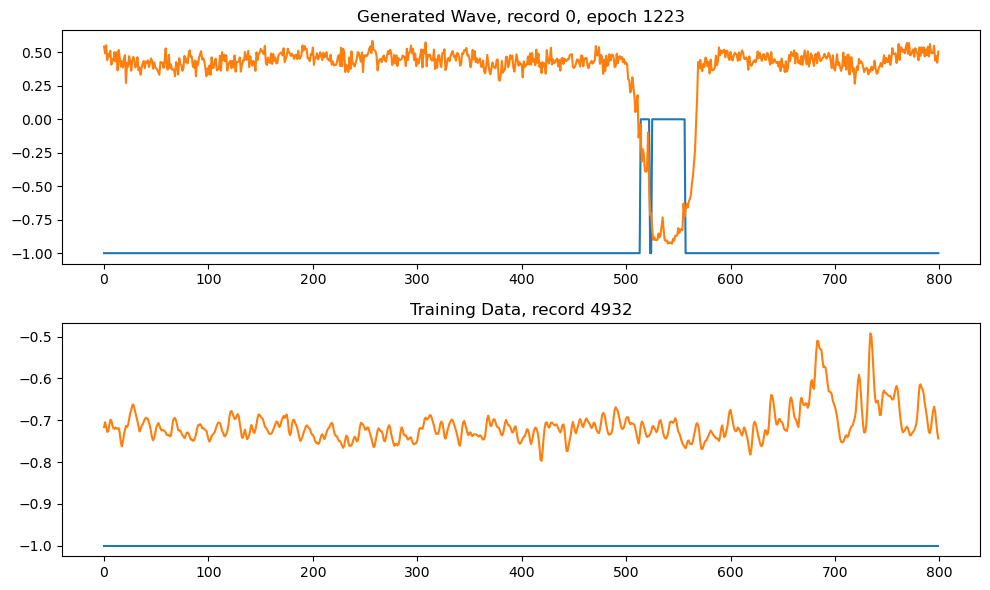

 39%|████████▏            | 197/504 [01:06<01:35,  3.21it/s]

In [ ]:
writeNow=False

epochs=5000

train(training_dataset, fake_dataset, epochs)

In [ ]:
steps_per_epoch

In [ ]:
fake_data